In [2]:
import spatialdata as sd
import scanpy as sc
import numpy as np
import pandas as pd
import squidpy as sq

Just a quick check regarding 0 count cells by segmentation

In [2]:
samples = ["1H","1D","2H","2D","3H","3D","4H","4D"]

In [3]:
zero_cells = {}
for sample in samples:
    for table in ["table","Baysor"]:
        sdata = sd.read_zarr(f"Version 2 Baysor Zarr//Sample_{sample}_annotated.zarr")
        adata = sdata.tables["table"]
        cell_counts = np.array(adata.X.sum(axis=1)).flatten()
        zero_count_cells = np.sum(cell_counts == 0)
        zero_cells[f"{sample}_{table}"] = zero_count_cells

In [6]:
zero_cells

{'1H_table': 183,
 '1H_Baysor': 183,
 '1D_table': 908,
 '1D_Baysor': 908,
 '2H_table': 607,
 '2H_Baysor': 607,
 '2D_table': 13205,
 '2D_Baysor': 13205,
 '3H_table': 129,
 '3H_Baysor': 129,
 '3D_table': 1208,
 '3D_Baysor': 1208,
 '4H_table': 85,
 '4H_Baysor': 85,
 '4D_table': 1675,
 '4D_Baysor': 1675}

In [2]:
sdata = sd.read_zarr(f"Version 2 Baysor Zarr//Sample_4H_annotated.zarr")

In [3]:
sdata.tables["Baysor"].obs["sample"] = "4H"
sdata.tables["Baysor"].obs["donor"] = "4"
sdata.tables["Baysor"].obs["condition"] = "healthy"

In [4]:
sdata.tables["Baysor"].obs["plaque_region"].unique

<bound method Series.unique of CR418b7a18c-1         Media
CR418b7a18c-10        Media
CR418b7a18c-100       Media
CR418b7a18c-1000     Intima
CR418b7a18c-10000     Media
                      ...  
CR418b7a18c-9996     Intima
CR418b7a18c-9997      Media
CR418b7a18c-9998     Intima
CR418b7a18c-9999     Intima
nan                  Intima
Name: plaque_region, Length: 25514, dtype: category
Categories (3, object): ['Intima', 'Media', 'Thrombus']>

In [5]:
merge_mapping = {
    "Intima_2": "Intima"
}
sdata.tables["Baysor"].obs["plaque_region"] = sdata.tables["Baysor"].obs["plaque_region"].replace(merge_mapping)

C:\Users\laure\AppData\Local\Temp\ipykernel_14312\3885936074.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  sdata.tables["Baysor"].obs["plaque_region"] = sdata.tables["Baysor"].obs["plaque_region"].replace(merge_mapping)


In [5]:
sc.pp.filter_cells(sdata.tables["Baysor"], min_counts=1)
sc.pp.neighbors(sdata.tables["Baysor"])
sc.tl.umap(sdata.tables["Baysor"])

         Falling back to preprocessing with `sc.pp.pca` and default params.


c:\Users\laure\anaconda3\envs\cluster_var\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
sc.tl.leiden(sdata.tables["Baysor"], resolution=1)

C:\Users\laure\AppData\Local\Temp\ipykernel_13940\524037045.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(sdata.tables["Baysor"], resolution=1)


In [9]:
level1_marker = {
    'Bcell': ['CD79A', 'CD79B', 'MS4A1', 'IGKC', 'CD22', 'FCER2'],
    'Plasma cell': ['IGKC', 'IGHM', 'IGHA1', 'IGLC2', 'IGLC3', 'JCHAIN'],
    'Tcell': ['CD2', 'TRAC', 'CD69', 'CD3D', 'CD3E', 'CD4', 'CD8A', 'CD8B', 'EOMES', 'LAG3'],
    'NK': ['NKG7', 'XCL1', 'CTSW', 'XCL2', 'CD160', 'FCGR3A', 'PRF1', 'GNLY'],
    'DC': ['CLEC10A', 'FCER1A', 'CD1C', 'HLA-DRA', 'HLA-DRB1'],
    'EC': ['PECAM1', 'VWF', 'FABP4', 'CLDN5', 'IFI27', 'ECSCR', 'DYSF', 'CD34', 'COL4A1', 'COL4A2', 'SPARCL1', 'PLVAP', 'MPZL2', 'SULF1', 'EDN1'],
    'Fibroblast': ['LUM', 'DCN', 'COL1A1', 'COL1A2', 'FBLN1', 'THY1'],
    'Fibromyocyte': ['FN1', 'LUM', 'TNFRSF11B',"TDT", 'ACTA2', 'C3', 'C7', "TCF21"],
    'SMC': ['ACTA2', 'MYH11', 'MYL9', 'TPM2', 'CALD1', 'TAGLN', 'TNFRSF11B', 'LUM', 'APOE', 'APOC1', 'AGT', 'NOTCH3', 'PDGFRB', 'MFAP4'],
    'Macrophage': ['C1QA', 'C1QB', 'C1QC', 'CD74', 'CXCL8', 'AIF1', 'CD14', 'CD68', 'ITGAM', 'CSF1R', 'HLA-DRA', 'LGALS3'],
    'Monocyte': ['FCN1', 'S100A8', 'S100A9', 'S100A12', 'VCAN', 'CD52', 'LYZ', 'CTSS'],
    'Mast': ['TPSAB1', 'TPSB2', 'KIT', 'HDC', 'CMA1'],
}

In [6]:
marker_genes_in_data = {}
for celltype in level1_marker:
    marker_genes_in_data[celltype] = list(set(level1_marker[celltype]).intersection(sdata.tables["Baysor"].var_names))
    print(celltype, len(set(level1_marker[celltype]).intersection(sdata.tables["Baysor"].var_names))/len(level1_marker[celltype]))
    print("not included: ", set(level1_marker[celltype]).difference(sdata.tables["Baysor"].var_names))

NameError: name 'sdata' is not defined

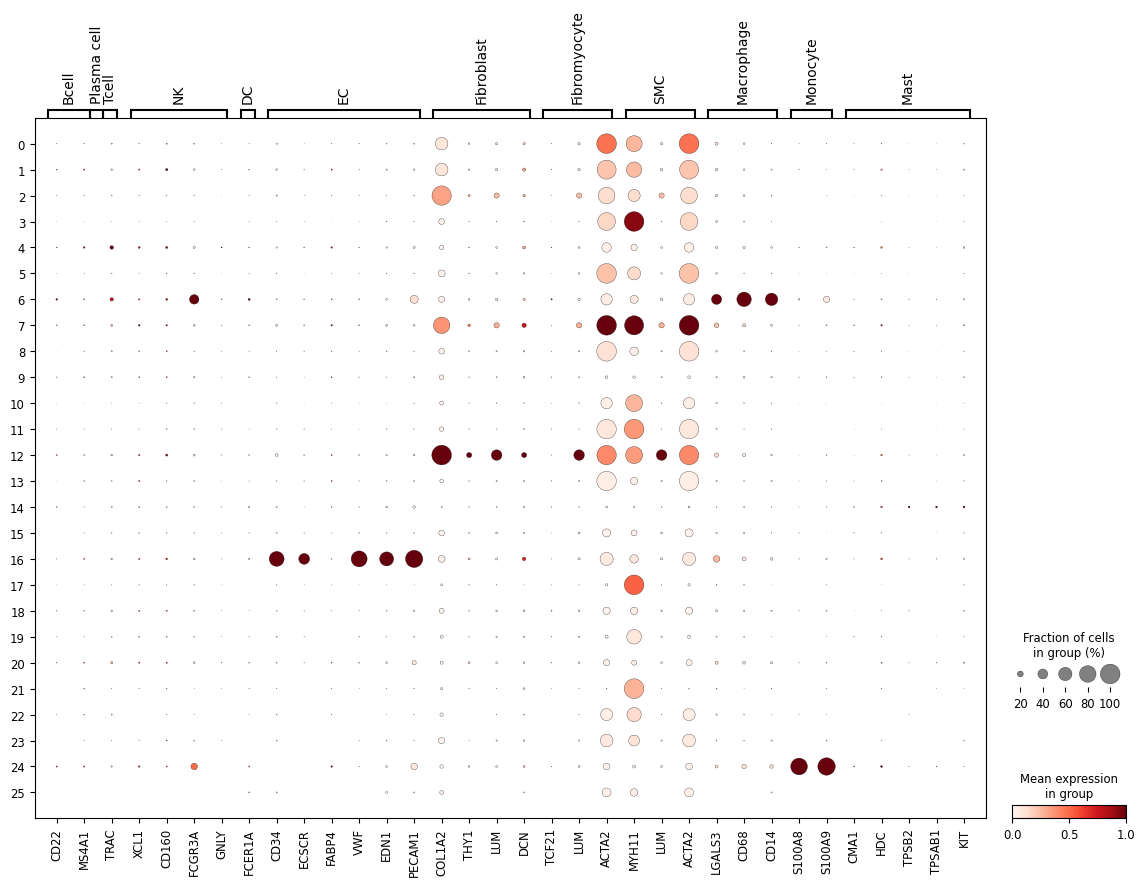

In [9]:
sc.pl.dotplot(
    sdata.tables["Baysor"],
    groupby="leiden",
    var_names=marker_genes_in_data,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
    save="dotplot_4H.png",
)

In [10]:
sdata.tables["Baysor"].obs["leiden"].value_counts()

leiden
0     2363
1     2184
2     1779
3     1627
4     1546
5     1510
6     1351
7     1281
8     1280
9      997
10     949
11     808
12     674
13     604
14     547
15     539
16     504
17     462
18     443
19     423
20     261
21     248
22     195
23     149
24     109
25      43
Name: count, dtype: int64

In [11]:
compact_mapping = {
    "unknown": ["4","9","14","15","18","20"],
    "Fibroblast": ["12"],
    "SMC": ["0","1","2","3","5","7","8","10","11","13","17","19","21","22","23","25"],
    "Macrophage": ["6"],
    "Monocyte": ["24"],
    "EC": ["16"]
}

In [12]:
mapping_dict = {key: value for value, keys in compact_mapping.items() for key in keys}

In [13]:
sdata.tables["Baysor"].obs["cell_type"] = sdata.tables["Baysor"].obs["leiden"].replace(mapping_dict)

C:\Users\laure\AppData\Local\Temp\ipykernel_13940\2967971444.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  sdata.tables["Baysor"].obs["cell_type"] = sdata.tables["Baysor"].obs["leiden"].replace(mapping_dict)


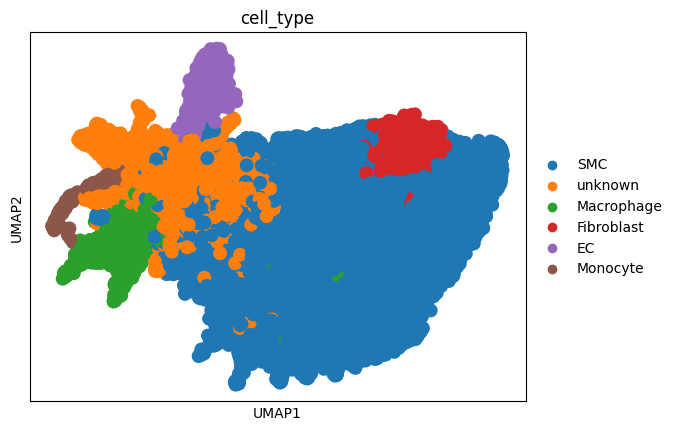

In [14]:
sc.pl.umap(sdata.tables["Baysor"], color=['cell_type'], s=400)

In [15]:
sdata.tables["Baysor"].obs["cell_type"].value_counts()

cell_type
SMC           15905
unknown        4333
Macrophage     1351
Fibroblast      674
EC              504
Monocyte        109
Name: count, dtype: int64

C:\Users\laure\Desktop\github\spatial_de\squidpy\src\squidpy\pl\_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


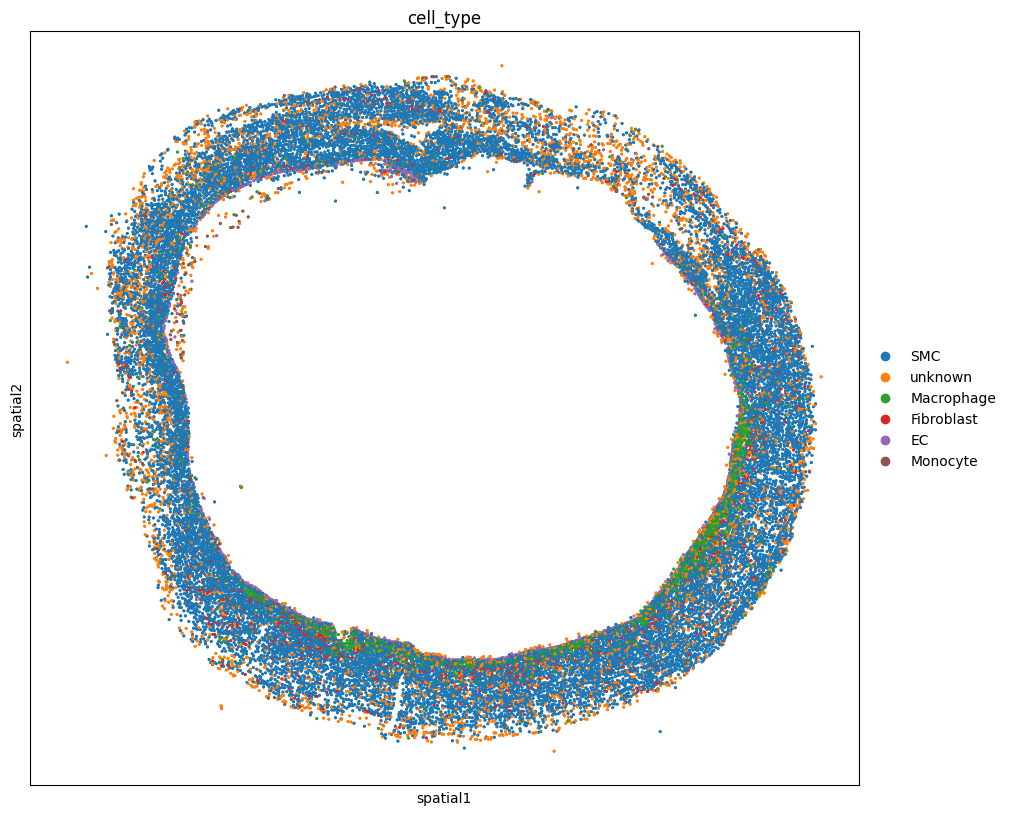

In [16]:
sq.pl.spatial_scatter(
    sdata.tables["Baysor"], color=['cell_type'], shape=None, figsize=(10, 10)
)

In [21]:
sdata.tables["Baysor"].uns.pop('leiden_colors')

['#023fa5',
 '#7d87b9',
 '#bec1d4',
 '#d6bcc0',
 '#bb7784',
 '#8e063b',
 '#4a6fe3',
 '#8595e1',
 '#b5bbe3',
 '#e6afb9',
 '#e07b91',
 '#d33f6a',
 '#11c638',
 '#8dd593',
 '#c6dec7',
 '#ead3c6',
 '#f0b98d',
 '#ef9708',
 '#0fcfc0',
 '#9cded6',
 '#d5eae7',
 '#f3e1eb',
 '#f6c4e1',
 '#f79cd4',
 '#7f7f7f',
 '#c7c7c7']

In [17]:
sdata.write("Version 2 Baysor cell type Zarr//Sample_4H_annotated.zarr")

INFO     The Zarr file used for backing will now change from Version 2 Baysor Zarr\Sample_4H_annotated.zarr to     
         Version 2 Baysor cell type Zarr\Sample_4H_annotated.zarr                                                  
